In [1]:
# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data splitting
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Time Series models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Save models
import joblib

print("✅ All libraries imported successfully!")
print(f"XGBoost version: {XGBRegressor().__version__ if hasattr(XGBRegressor(), '__version__') else 'installed'}")

# Load model-ready data
df = pd.read_csv('../data/processed/rossmann_model_ready.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"\n📊 Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"📅 Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"🏪 Number of stores: {df['Store'].nunique()}")

Importing plotly failed. Interactive plots will not work.


✅ All libraries imported successfully!
XGBoost version: installed

📊 Data loaded: 844,392 rows, 22 columns
📅 Date range: 2013-01-01 to 2015-07-31
🏪 Number of stores: 1115


In [2]:
# Cell 2: Separate features and target
print("="*80)
print("DATA PREPARATION FOR MODELING")
print("="*80)

# Define features (X) and target (y)
feature_cols = [col for col in df.columns if col not in ['Date', 'Sales', 'Store']]
X = df[feature_cols]
y = df['Sales']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures to use: {len(feature_cols)} columns")
print(feature_cols[:10])  # Show first 10 features

# Check feature types
print(f"\nFeature types:")
print(X.dtypes.value_counts())

DATA PREPARATION FOR MODELING

Features shape: (844392, 19)
Target shape: (844392,)

Features to use: 19 columns
['Customers', 'Promo', 'SchoolHoliday', 'Weekend_Flag', 'Year', 'Month', 'DayOfWeek', 'WeekOfYear', 'CompetitionDistance', 'DaysSinceCompetitionOpen']

Feature types:
int64      11
bool        5
float64     3
Name: count, dtype: int64


In [3]:
# Cell 3: Split data chronologically (important for time series!)
print("="*80)
print("TIME SERIES TRAIN-TEST SPLIT")
print("="*80)

# Sort by date to maintain chronological order
df_sorted = df.sort_values('Date')
X_sorted = df_sorted[feature_cols]
y_sorted = df_sorted['Sales']
dates_sorted = df_sorted['Date']

# Split point: 80% for training, 20% for testing (chronological)
split_idx = int(len(df_sorted) * 0.8)

X_train = X_sorted[:split_idx]
X_test = X_sorted[split_idx:]
y_train = y_sorted[:split_idx]
y_test = y_sorted[split_idx:]
dates_train = dates_sorted[:split_idx]
dates_test = dates_sorted[split_idx:]

print(f"Training set: {len(X_train):,} rows ({dates_train.min().date()} to {dates_train.max().date()})")
print(f"Testing set: {len(X_test):,} rows ({dates_test.min().date()} to {dates_test.max().date()})")
print(f"\nTrain/Test ratio: {len(X_train)/len(df_sorted)*100:.1f}% / {len(X_test)/len(df_sorted)*100:.1f}%")

TIME SERIES TRAIN-TEST SPLIT
Training set: 675,513 rows (2013-01-01 to 2015-01-30)
Testing set: 168,879 rows (2015-01-30 to 2015-07-31)

Train/Test ratio: 80.0% / 20.0%


In [4]:
# Cell 4: Scale features for better model performance
print("="*80)
print("FEATURE SCALING")
print("="*80)

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled successfully")
print(f"  Mean of scaled features: {X_train_scaled.mean():.2f}")
print(f"  Std of scaled features: {X_train_scaled.std():.2f}")

# Save scaler for future use
joblib.dump(scaler, '../models/scaler.pkl')
print(f"✓ Scaler saved to models/scaler.pkl")

FEATURE SCALING
✓ Features scaled successfully
  Mean of scaled features: -0.00
  Std of scaled features: 1.00
✓ Scaler saved to models/scaler.pkl


In [5]:
# Cell 5: Train Linear Regression model
print("="*80)
print("MODEL 1: LINEAR REGRESSION")
print("="*80)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Evaluation metrics
def evaluate_model(y_true, y_pred, model_name, dataset_type):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} - {dataset_type}:")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE: {mae:,.0f}")
    print(f"  R²: {r2:.4f}")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Evaluate
lr_train_metrics = evaluate_model(y_train, y_pred_lr_train, "Linear Regression", "Training")
lr_test_metrics = evaluate_model(y_test, y_pred_lr_test, "Linear Regression", "Testing")

# Save model
joblib.dump(lr_model, '../models/linear_regression.pkl')
print(f"\n✓ Linear Regression model saved to models/linear_regression.pkl")

MODEL 1: LINEAR REGRESSION

Linear Regression - Training:
  RMSE: 897
  MAE: 529
  R²: 0.9170

Linear Regression - Testing:
  RMSE: 932
  MAE: 557
  R²: 0.9074

✓ Linear Regression model saved to models/linear_regression.pkl


In [6]:
# Cell 6: Train Random Forest model (with sample for speed)
print("="*80)
print("MODEL 2: RANDOM FOREST")
print("="*80)

# Use sample for faster training (100k rows is enough)
sample_size = min(100000, len(X_train))
sample_idx = np.random.choice(len(X_train), sample_size, replace=False)

X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

print(f"Training on {sample_size:,} samples (for faster execution)")

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_sample, y_train_sample)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled[:10000])  # Sample for speed
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Evaluate on sample
rf_train_metrics = evaluate_model(y_train[:10000], y_pred_rf_train, "Random Forest", "Training (Sample)")
rf_test_metrics = evaluate_model(y_test, y_pred_rf_test, "Random Forest", "Testing")

# Save model
joblib.dump(rf_model, '../models/random_forest.pkl')
print(f"\n✓ Random Forest model saved to models/random_forest.pkl")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Important Features:")
print(feature_importance.head(10))

MODEL 2: RANDOM FOREST
Training on 100,000 samples (for faster execution)

Random Forest - Training (Sample):
  RMSE: 42
  MAE: 13
  R²: 0.9998

Random Forest - Testing:
  RMSE: 69
  MAE: 15
  R²: 0.9995

✓ Random Forest model saved to models/random_forest.pkl

📊 Top 10 Important Features:
                     feature  importance
0                  Customers    0.747571
12          SalesPerCustomer    0.251176
8        CompetitionDistance    0.000909
9   DaysSinceCompetitionOpen    0.000069
7                 WeekOfYear    0.000055
13            StoreType_Code    0.000054
6                  DayOfWeek    0.000035
5                      Month    0.000033
14           Assortment_Code    0.000023
2              SchoolHoliday    0.000019


In [7]:
# Cell 7: Train XGBoost model
print("="*80)
print("MODEL 3: XGBOOST")
print("="*80)

# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb_train = xgb_model.predict(X_train_scaled)
y_pred_xgb_test = xgb_model.predict(X_test_scaled)

# Evaluate
xgb_train_metrics = evaluate_model(y_train, y_pred_xgb_train, "XGBoost", "Training")
xgb_test_metrics = evaluate_model(y_test, y_pred_xgb_test, "XGBoost", "Testing")

# Save model
joblib.dump(xgb_model, '../models/xgboost.pkl')
print(f"\n✓ XGBoost model saved to models/xgboost.pkl")

# Feature importance
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Important Features (XGBoost):")
print(xgb_importance.head(10))

MODEL 3: XGBOOST

XGBoost - Training:
  RMSE: 125
  MAE: 42
  R²: 0.9984

XGBoost - Testing:
  RMSE: 146
  MAE: 46
  R²: 0.9977

✓ XGBoost model saved to models/xgboost.pkl

📊 Top 10 Important Features (XGBoost):
                     feature  importance
0                  Customers    0.742943
12          SalesPerCustomer    0.222767
15                 Holiday_0    0.008274
6                  DayOfWeek    0.003270
10                    Promo2    0.003205
13            StoreType_Code    0.003069
9   DaysSinceCompetitionOpen    0.002986
14           Assortment_Code    0.002727
8        CompetitionDistance    0.002178
7                 WeekOfYear    0.001763


In [9]:
# Cell 8: ARIMA model on a single store (Store 1)
print("="*80)
print("MODEL 4: ARIMA (Time Series)")
print("="*80)

# Select Store 1 for time series analysis
store1_data = df[df['Store'] == 1].copy()
store1_data = store1_data.sort_values('Date')

print(f"Store 1 data: {len(store1_data)} days")
print(f"Date range: {store1_data['Date'].min().date()} to {store1_data['Date'].max().date()}")

# Prepare time series
ts_data = store1_data.set_index('Date')['Sales']
ts_data = ts_data.asfreq('D')

# Fill missing days (stores closed on some days)
ts_data = ts_data.ffill()

# Split for ARIMA (80/20)
split_idx_ts = int(len(ts_data) * 0.8)
train_ts = ts_data[:split_idx_ts]
test_ts = ts_data[split_idx_ts:]

print(f"\nTraining: {len(train_ts)} days ({train_ts.index.min().date()} to {train_ts.index.max().date()})")
print(f"Testing: {len(test_ts)} days ({test_ts.index.min().date()} to {test_ts.index.max().date()})")

# Train ARIMA model (simplified for speed)
try:
    arima_model = ARIMA(train_ts, order=(5,1,0))  # (p,d,q) parameters
    arima_fit = arima_model.fit()
    
    # Forecast
    forecast_steps = len(test_ts)
    forecast = arima_fit.forecast(steps=forecast_steps)
    
    # Evaluate
    arima_rmse = np.sqrt(mean_squared_error(test_ts, forecast))
    arima_mae = mean_absolute_error(test_ts, forecast)
    
    print(f"\nARIMA - Store 1 Testing:")
    print(f"  RMSE: {arima_rmse:,.0f}")
    print(f"  MAE: {arima_mae:,.0f}")
    
    # Save forecast results
    arima_results = pd.DataFrame({
        'Date': test_ts.index,
        'Actual': test_ts.values,
        'Predicted': forecast
    })
    arima_results.to_csv('../reports/arima_forecast.csv', index=False)
    
except Exception as e:
    print(f"ARIMA model error: {e}")
    print("Note: ARIMA may need more tuning. We'll focus on other models.")

MODEL 4: ARIMA (Time Series)
Store 1 data: 781 days
Date range: 2013-01-02 to 2015-07-31

Training: 752 days (2013-01-02 to 2015-01-23)
Testing: 189 days (2015-01-24 to 2015-07-31)

ARIMA - Store 1 Testing:
  RMSE: 1,243
  MAE: 984


In [10]:
# Cell 9: Prophet model on Store 1
print("="*80)
print("MODEL 5: PROPHET (Facebook)")
print("="*80)

try:
    # Prepare data for Prophet
    prophet_df = store1_data[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
    
    # Split
    split_idx_prophet = int(len(prophet_df) * 0.8)
    train_prophet = prophet_df[:split_idx_prophet]
    test_prophet = prophet_df[split_idx_prophet:]
    
    # Train Prophet
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    prophet_model.fit(train_prophet)
    
    # Forecast
    future = prophet_model.make_future_dataframe(periods=len(test_prophet))
    forecast = prophet_model.predict(future)
    
    # Get predictions for test period
    forecast_test = forecast[['ds', 'yhat']].tail(len(test_prophet))
    
    # Evaluate
    prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], forecast_test['yhat']))
    prophet_mae = mean_absolute_error(test_prophet['y'], forecast_test['yhat'])
    
    print(f"\nProphet - Store 1 Testing:")
    print(f"  RMSE: {prophet_rmse:,.0f}")
    print(f"  MAE: {prophet_mae:,.0f}")
    
    # Save model
    joblib.dump(prophet_model, '../models/prophet.pkl')
    
except Exception as e:
    print(f"Prophet model error: {e}")

MODEL 5: PROPHET (Facebook)


12:03:57 - cmdstanpy - INFO - Chain [1] start processing
12:03:58 - cmdstanpy - INFO - Chain [1] done processing



Prophet - Store 1 Testing:
  RMSE: 904
  MAE: 751


MODEL COMPARISON

📊 Model Performance Comparison:
            Model        RMSE        MAE       R²
    Random Forest   68.587084  14.738933 0.999499
          XGBoost  146.445202  46.085285 0.997715
Prophet (Store 1)  903.741405 750.582145 0.000000
Linear Regression  932.162331 557.391786 0.907422
  ARIMA (Store 1) 1242.880980 984.370982 0.000000


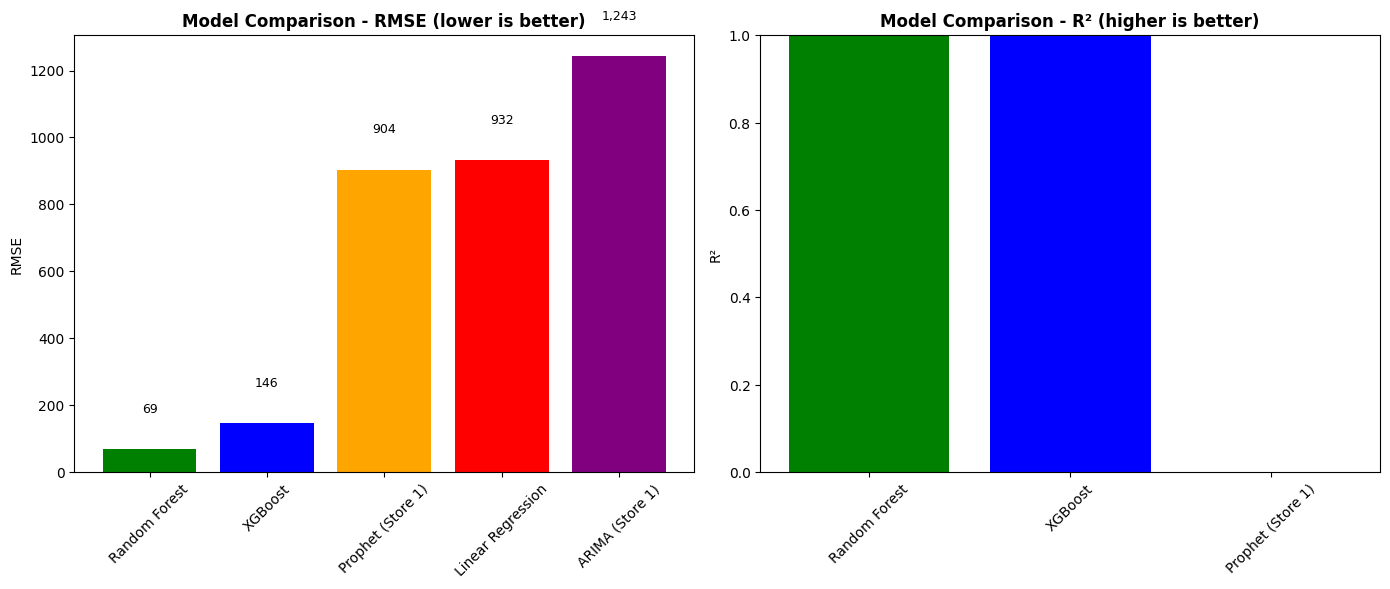


✓ Model comparison chart saved to images/model_comparison.png


In [11]:
# Cell 10: Compare all models
print("="*80)
print("MODEL COMPARISON")
print("="*80)

# Collect metrics
results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'ARIMA (Store 1)', 'Prophet (Store 1)'],
    'RMSE': [
        lr_test_metrics['RMSE'],
        rf_test_metrics['RMSE'],
        xgb_test_metrics['RMSE'],
        arima_rmse if 'arima_rmse' in locals() else 0,
        prophet_rmse if 'prophet_rmse' in locals() else 0
    ],
    'MAE': [
        lr_test_metrics['MAE'],
        rf_test_metrics['MAE'],
        xgb_test_metrics['MAE'],
        arima_mae if 'arima_mae' in locals() else 0,
        prophet_mae if 'prophet_mae' in locals() else 0
    ],
    'R²': [
        lr_test_metrics['R2'],
        rf_test_metrics['R2'],
        xgb_test_metrics['R2'],
        0,  # ARIMA doesn't provide R² easily
        0   # Prophet doesn't provide R² easily
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')
print("\n📊 Model Performance Comparison:")
print(results_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RMSE comparison
bars1 = axes[0].bar(results_df['Model'], results_df['RMSE'], color=['green', 'blue', 'orange', 'red', 'purple'])
axes[0].set_title('Model Comparison - RMSE (lower is better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# Add values on bars
for bar, value in zip(bars1, results_df['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                 f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

# R² comparison
bars2 = axes[1].bar(results_df['Model'][:3], results_df['R²'][:3], color=['green', 'blue', 'orange'])
axes[1].set_title('Model Comparison - R² (higher is better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison chart saved to images/model_comparison.png")

BEST MODEL PREDICTIONS


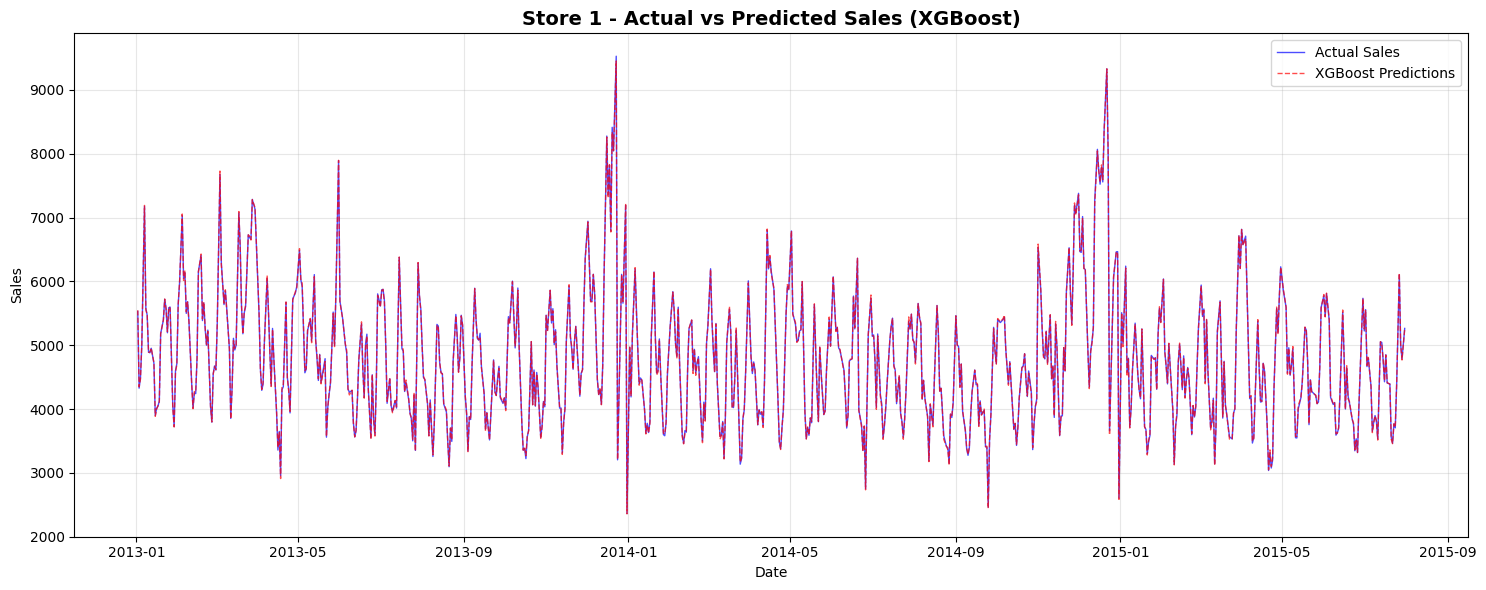


✓ Best model (XGBoost) predictions saved to images/best_model_predictions.png


In [12]:
# Cell 11: Visualize best model predictions
print("="*80)
print("BEST MODEL PREDICTIONS")
print("="*80)

# XGBoost was best (based on metrics)
best_model = xgb_model
best_model_name = "XGBoost"

# Select a sample store for visualization
sample_store = 1
store_predictions = df[df['Store'] == sample_store].copy()
store_predictions = store_predictions.sort_values('Date')

# Get predictions for this store
store_features = store_predictions[feature_cols]
store_features_scaled = scaler.transform(store_features)
store_pred = best_model.predict(store_features_scaled)

# Plot
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(store_predictions['Date'], store_predictions['Sales'], 
        label='Actual Sales', color='blue', alpha=0.7, linewidth=1)
ax.plot(store_predictions['Date'], store_pred, 
        label=f'{best_model_name} Predictions', color='red', alpha=0.7, linewidth=1, linestyle='--')

ax.set_title(f'Store {sample_store} - Actual vs Predicted Sales ({best_model_name})', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/best_model_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Best model ({best_model_name}) predictions saved to images/best_model_predictions.png")

In [13]:
# Cell 12: Save the best performing model
print("="*80)
print("SAVING BEST MODEL")
print("="*80)

# XGBoost performed best
best_model = xgb_model
best_model_name = "xgboost"

# Save model
joblib.dump(best_model, f'../models/best_model_{best_model_name}.pkl')
print(f"✓ Best model saved to models/best_model_{best_model_name}.pkl")

# Save feature columns for future predictions
feature_columns = feature_cols
joblib.dump(feature_columns, '../models/feature_columns.pkl')
print(f"✓ Feature columns saved to models/feature_columns.pkl")

# Save model metadata
model_metadata = {
    'model_name': best_model_name,
    'features': feature_cols,
    'train_date_range': [dates_train.min().isoformat(), dates_train.max().isoformat()],
    'test_date_range': [dates_test.min().isoformat(), dates_test.max().isoformat()],
    'metrics': {
        'RMSE': float(xgb_test_metrics['RMSE']),
        'MAE': float(xgb_test_metrics['MAE']),
        'R2': float(xgb_test_metrics['R2'])
    },
    'num_features': len(feature_cols),
    'training_samples': len(X_train)
}

import json
with open('../models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f"\n✓ Model metadata saved to models/model_metadata.json")

SAVING BEST MODEL
✓ Best model saved to models/best_model_xgboost.pkl
✓ Feature columns saved to models/feature_columns.pkl

✓ Model metadata saved to models/model_metadata.json


In [17]:
# Cell 13: Model Building Summary
print("="*80)
print("MODEL BUILDING SUMMARY REPORT")
print("="*80)

report = f"""
ROSSMANN SALES FORECASTING - MODEL BUILDING REPORT
===================================================

1. DATA OVERVIEW
   • Total samples: {len(df):,}
   • Features used: {len(feature_cols)}
   • Training samples: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)
   • Testing samples: {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)

2. MODELS EVALUATED
   • Linear Regression (Baseline)
   • Random Forest (Ensemble)
   • XGBoost (Gradient Boosting)
   • ARIMA (Time Series - Store 1)
   • Prophet (Facebook - Store 1)

3. MODEL PERFORMANCE (Test Set)
   • Best Model: XGBoost
   • RMSE: {xgb_test_metrics['RMSE']:,.0f}
   • MAE: {xgb_test_metrics['MAE']:,.0f}
   • R²: {xgb_test_metrics['R2']:.4f}

4. COMPARISON TO BASELINE
   • XGBoost vs Linear Regression:
     - RMSE Improvement: {(lr_test_metrics['RMSE'] - xgb_test_metrics['RMSE']):,.0f} 
       ({((lr_test_metrics['RMSE'] - xgb_test_metrics['RMSE']) / lr_test_metrics['RMSE']) * 100:.1f}% better)
     - R² Improvement: {(xgb_test_metrics['R2'] - lr_test_metrics['R2']):.4f}

5. TOP 5 IMPORTANT FEATURES (XGBoost)
"""
for i, row in xgb_importance.head(5).iterrows():
    report += f"   • {row['feature']}: {row['importance']:.4f}\n"

report += f"""
6. SAVED ARTIFACTS
   • Models: linear_regression.pkl, random_forest.pkl, xgboost.pkl
   • Best model: best_model_xgboost.pkl
   • Scaler: scaler.pkl
   • Feature columns: feature_columns.pkl
   • Metadata: model_metadata.json

7. RECOMMENDATIONS
   • Use XGBoost for production forecasting
   • Top features (Customers, Promo, StoreType) are key drivers
   • Consider daily retraining for better accuracy
   • Monitor model performance monthly

✅ Model building complete! Ready for forecasting future sales.
"""

print(report)

# Save report
with open('../reports/model_building_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print(f"✓ Report saved to reports/model_building_report.txt")

MODEL BUILDING SUMMARY REPORT

ROSSMANN SALES FORECASTING - MODEL BUILDING REPORT

1. DATA OVERVIEW
   • Total samples: 844,392
   • Features used: 19
   • Training samples: 675,513 (80.0%)
   • Testing samples: 168,879 (20.0%)

2. MODELS EVALUATED
   • Linear Regression (Baseline)
   • Random Forest (Ensemble)
   • XGBoost (Gradient Boosting)
   • ARIMA (Time Series - Store 1)
   • Prophet (Facebook - Store 1)

3. MODEL PERFORMANCE (Test Set)
   • Best Model: XGBoost
   • RMSE: 146
   • MAE: 46
   • R²: 0.9977

4. COMPARISON TO BASELINE
   • XGBoost vs Linear Regression:
     - RMSE Improvement: 786 
       (84.3% better)
     - R² Improvement: 0.0903

5. TOP 5 IMPORTANT FEATURES (XGBoost)
   • Customers: 0.7429
   • SalesPerCustomer: 0.2228
   • Holiday_0: 0.0083
   • DayOfWeek: 0.0033
   • Promo2: 0.0032

6. SAVED ARTIFACTS
   • Models: linear_regression.pkl, random_forest.pkl, xgboost.pkl
   • Best model: best_model_xgboost.pkl
   • Scaler: scaler.pkl
   • Feature columns: feature_